In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

#Pandas	Data analysis
#NumPy	Numerical operations
#Matplotlib	Basic charts
#Seaborn	Advanced charts

In [2]:
df = pd.read_excel(r"C:\Users\yashb\Desktop\DA_Project_1\Unicorn_Companies-c1.xlsx")
# load excel into data frame 

In [4]:
df.head(10)

,Company,valuation,date_Joined,industry,city,country,continent,year_founded,funding,select_investors,unicorn-year,years_to_unicorn,valuation_b,fundings_b,fundings_category,valuation_efficiency
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S...",2017,5,180,8.000,High Funding,22.500000
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2012,10,100,7.000,High Funding,14.285714
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China...",2018,10,100,2.000,Medium Funding,50.000000
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG",2014,4,95,2.000,Medium Funding,47.500000
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita...",2011,6,46,4.000,High Funding,11.500000
5,Canva,$40B,2018-01-08,Internet software & services,Surry Hills,Australia,Oceania,2012,$572M,"Sequoia Capital China, Blackbird Ventures, Mat...",2018,6,40,0.572,Medium Funding,69.930070
6,Checkout.com,$40B,2019-05-02,Fintech,London,United Kingdom,Europe,2012,$2B,"Tiger Global Management, Insight Partners, DST...",2019,7,40,2.000,Medium Funding,20.000000
7,Instacart,$39B,2014-12-30,"Supply chain, logistics, & delivery",San Francisco,United States,North America,2012,$3B,"Khosla Ventures, Kleiner Perkins Caufield & By...",2014,2,39,3.000,High Funding,13.000000
8,JUUL Labs,$38B,2017-12-20,Consumer & retail,San Francisco,United States,North America,2015,$14B,Tiger Global Management,2017,2,38,14.000,High Funding,2.714286
9,Databricks,$38B,2019-02-05,Data management & analytics,San Francisco,United States,North America,2013,$3B,"Andreessen Horowitz, New Enterprise Associates...",2019,6,38,3.000,High Funding,12.666667


In [5]:
df.shape

(1074, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Company               1074 non-null   object        
 1   valuation             1074 non-null   object        
 2   date_Joined           1074 non-null   datetime64[ns]
 3   industry              1074 non-null   object        
 4   city                  1058 non-null   object        
 5   country               1074 non-null   object        
 6   continent             1074 non-null   object        
 7   year_founded          1074 non-null   int64         
 8   funding               1074 non-null   object        
 9   select_investors      1073 non-null   object        
 10  unicorn-year          1074 non-null   int64         
 11  years_to_unicorn      1074 non-null   int64         
 12  valuation_b           1074 non-null   int64         
 13  fundings_b        

In [8]:
#Check Missing Values

df.isnull().sum()

Company                  0
valuation                0
date_Joined              0
industry                 0
city                    16
country                  0
continent                0
year_founded             0
funding                  0
select_investors         1
unicorn-year             0
years_to_unicorn         0
valuation_b              0
fundings_b              12
fundings_category        0
valuation_efficiency     0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

Company                         object
valuation                       object
date_Joined             datetime64[ns]
industry                        object
city                            object
country                         object
continent                       object
year_founded                     int64
funding                         object
select_investors                object
unicorn-year                     int64
years_to_unicorn                 int64
valuation_b                      int64
fundings_b                     float64
fundings_category               object
valuation_efficiency           float64
dtype: object

In [14]:
df['Company'].nunique()

1073

In [15]:
df['country'].nunique()

46

In [16]:
df['industry'].nunique()

16

In [17]:
df['fundings_b'].describe()

count    1062.000000
mean        0.557269
std         0.810134
min         0.000000
25%         0.223000
50%         0.370000
75%         0.609250
max        14.000000
Name: fundings_b, dtype: float64

In [18]:
df['valuation_b'].describe()

count    1074.000000
mean        3.455307
std         8.547022
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       180.000000
Name: valuation_b, dtype: float64

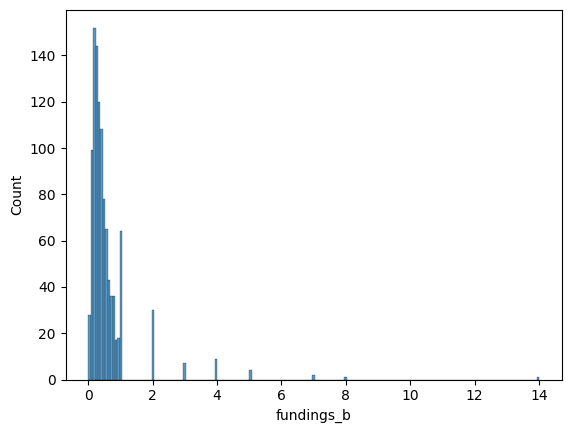

In [23]:
#Funding Distribution
sns.histplot(df['fundings_b'])
plt.show()


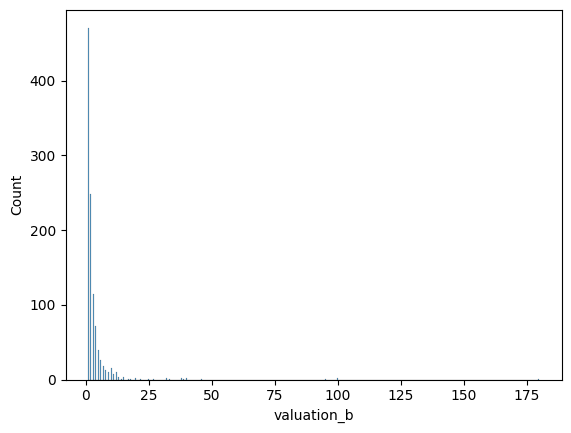

In [24]:
sns.histplot(df['valuation_b'])
plt.show()

In [21]:
#Funding vs Valuation
df[['fundings_b','valuation_b']].corr()
#0.00 → No relation
#0.50 → Moderate
#0.80+ → Strong

,fundings_b,valuation_b
fundings_b,1.000000,0.598384
valuation_b,0.598384,1.000000


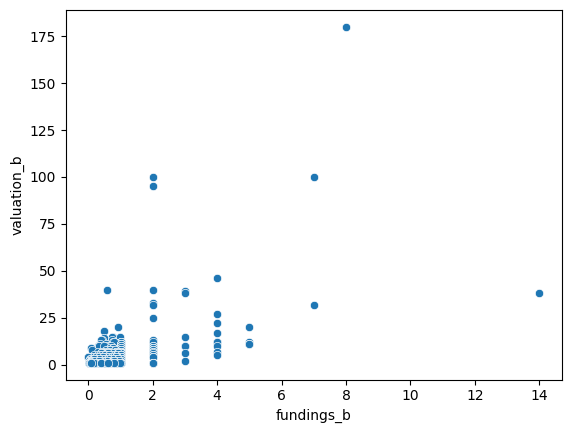

In [29]:
sns.scatterplot(
x='fundings_b',
y='valuation_b',
data=df
)

plt.show()

In [31]:
#Average Valuation by Industry
industry_val = (
df.groupby('industry')
['valuation_b']
.mean()
.sort_values(ascending=False)
)

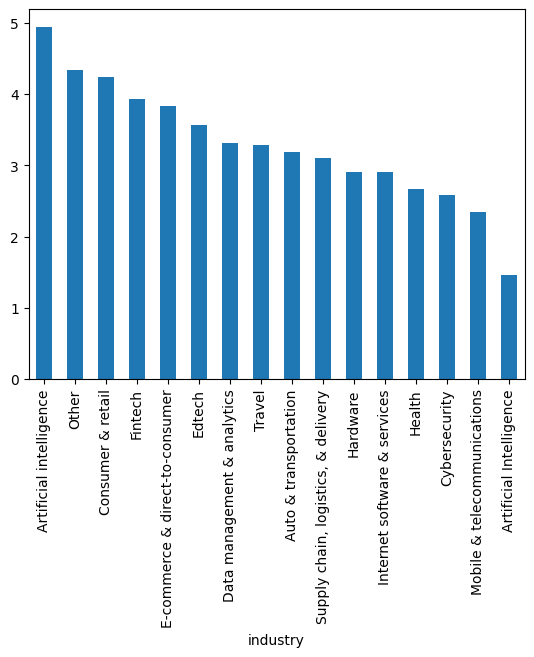

In [33]:
#Industry Valuation Chart
industry_val.plot(kind='bar')
plt.show()

In [34]:
#Average Funding by Industry
industry_fund = (
df.groupby('industry')
['fundings_b']
.mean()
.sort_values(ascending=False)
)

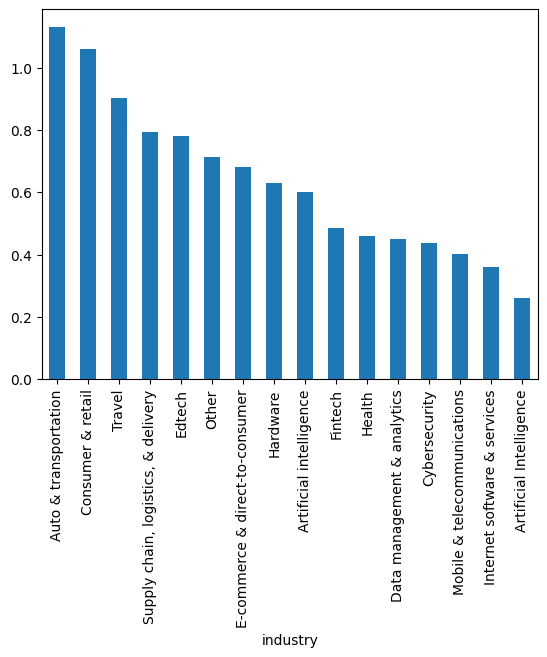

In [35]:
industry_fund.plot(kind='bar')
plt.show()

In [36]:
df['country'].value_counts().head(10)

country
United States     562
China             173
India              65
United Kingdom     43
Germany            26
France             24
Israel             20
Canada             19
Brazil             16
Singapore          12
Name: count, dtype: int64

In [37]:
efficiency = (
df.groupby('industry')
['valuation_efficiency']
.mean()
.sort_values(ascending=False)
)

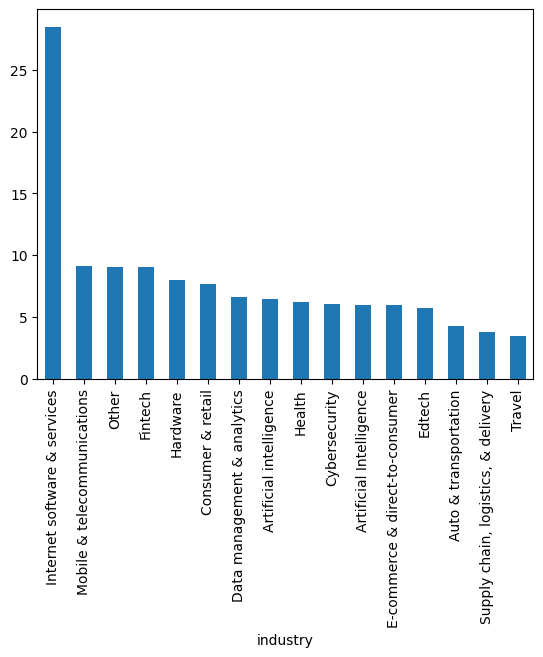

In [38]:
efficiency.plot(kind='bar')
plt.show()
#Which industries generate the most valuation per dollar invested?

In [39]:
growth = (
df.groupby('industry')
['years_to_unicorn']
.mean()
.sort_values()
)

In [41]:
growth = (
df.groupby('industry')
['years_to_unicorn']
.mean()
.sort_values()
)

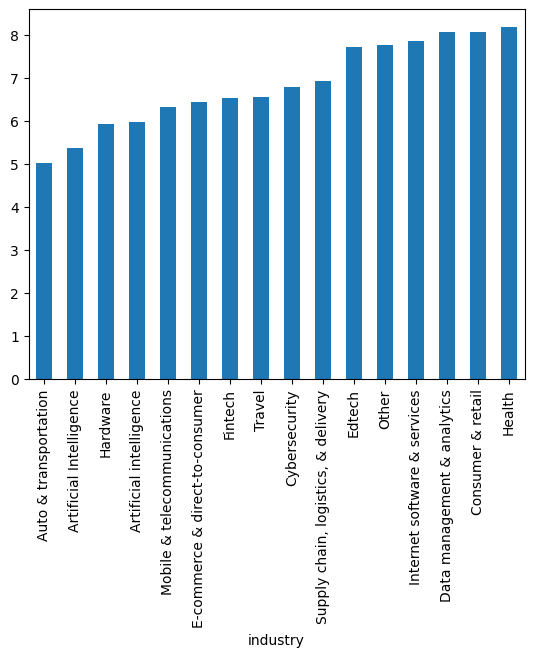

In [42]:
growth.plot(kind='bar')
plt.show()